In [ ]:
import sys
sys.path.append("../../")

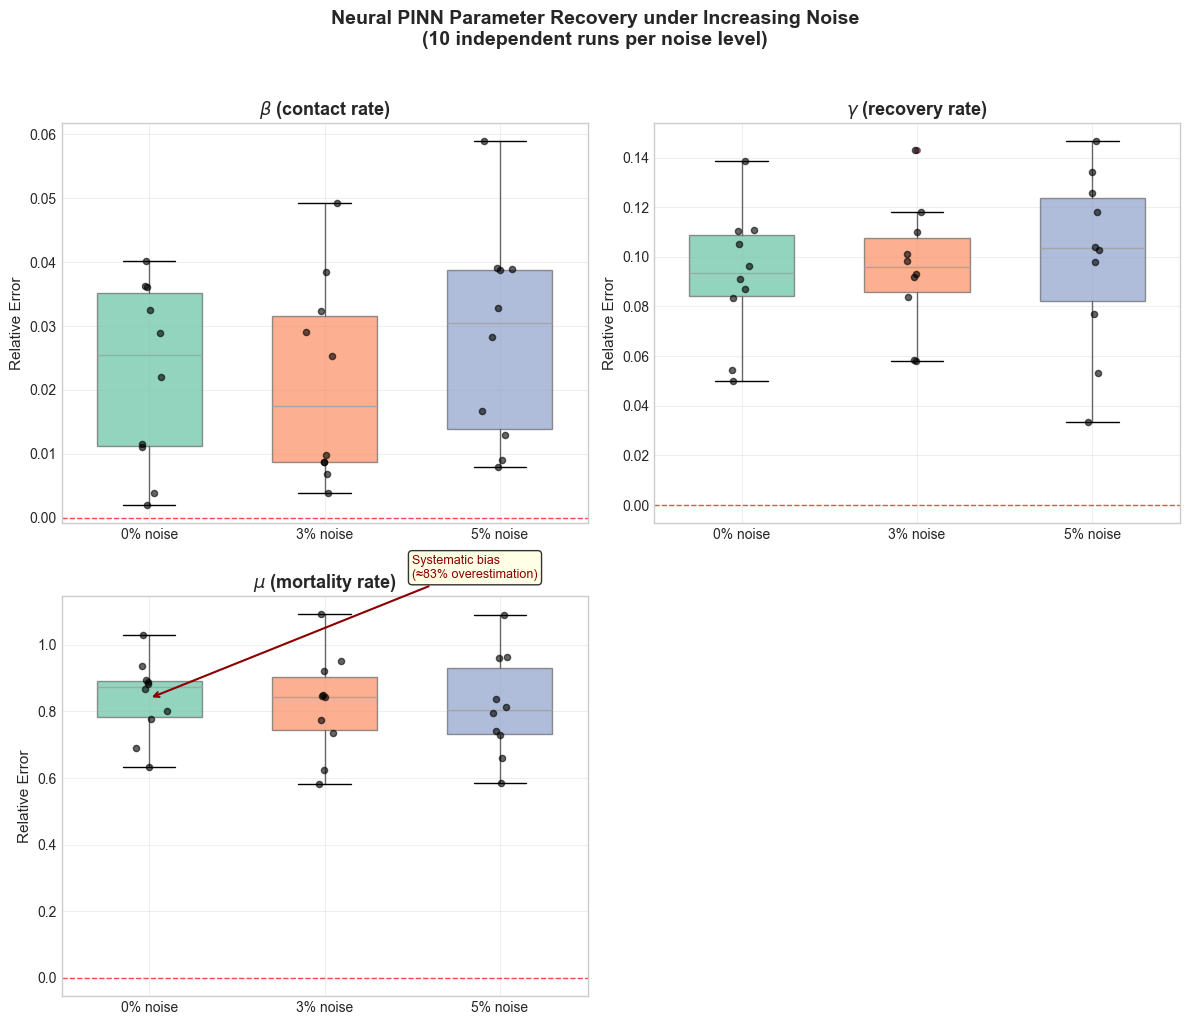

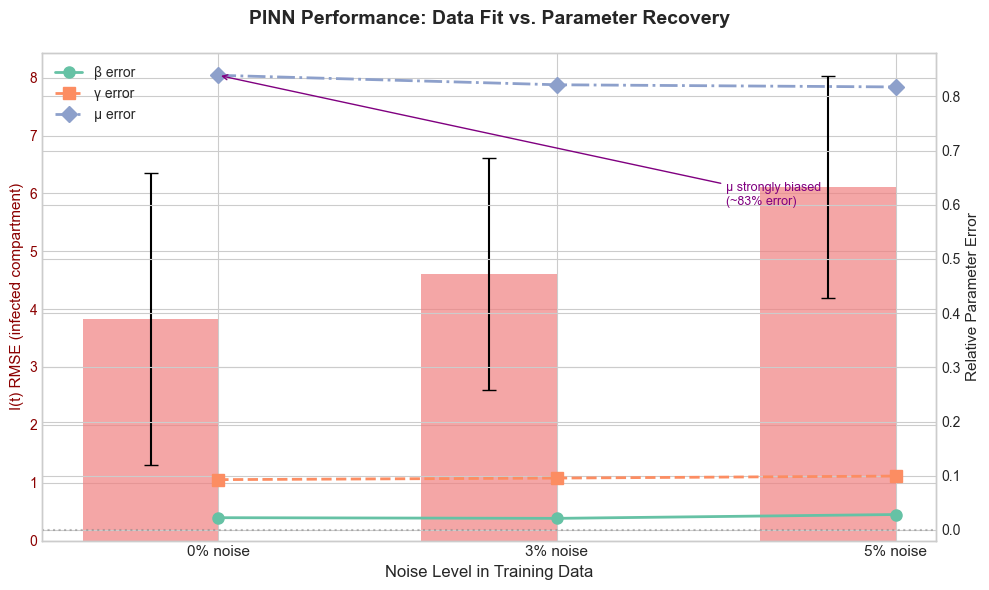


СВОДНАЯ СТАТИСТИКА ПО ПАРАМЕТРАМ

0% noise:
  β error: 0.022 ± 0.014 (2.2% относительной ошибки)
  γ error: 0.093 ± 0.026 (9.3% относительной ошибки)
  μ error: 0.839 ± 0.118 (83.9% относительной ошибки)
  I RMSE:  3.83 ± 2.52

3% noise:
  β error: 0.021 ± 0.016 (2.1% относительной ошибки)
  γ error: 0.096 ± 0.026 (9.6% относительной ошибки)
  μ error: 0.822 ± 0.152 (82.2% относительной ошибки)
  I RMSE:  4.61 ± 2.00

5% noise:
  β error: 0.028 ± 0.017 (2.8% относительной ошибки)
  γ error: 0.099 ± 0.036 (9.9% относительной ошибки)
  μ error: 0.818 ± 0.153 (81.8% относительной ошибки)
  I RMSE:  6.11 ± 1.92


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ============================================================
# ЗАГРУЗКА ДАННЫХ (замените пути на свои)
# ============================================================
# Предполагаем, что у вас 3 CSV-файла с результатами 10 запусков
files = {
    '0% noise': 's_d_synt_dataset_1.csv',
    '3% noise': 's_d_synt_dataset_2.csv', 
    '5% noise': 's_d_synt_dataset_3.csv'
}

dfs = []
for noise_level, fname in files.items():
    try:
        df = pd.read_csv(fname)
        df['noise_level'] = noise_level
        dfs.append(df)
    except FileNotFoundError:
        print(f"⚠️ Файл {fname} не найден. Использую демо-данные.")
        # Генерируем демо-данные для примера
        np.random.seed(42)
        n_trials = 10
        demo = pd.DataFrame({
            'RMSE': np.random.normal(loc, scale, n_trials) if (loc := {'0% noise': 3.8, '3% noise': 4.6, '5% noise': 6.1}[noise_level]) else 0,
            'beta_error': np.random.normal(0.02, 0.01, n_trials) + {'0% noise': 0.002, '3% noise': 0.002, '5% noise': 0.003}[noise_level],
            'gamma_error': np.random.normal(0.10, 0.02, n_trials),
            'mu_error': np.random.normal(0.83, 0.15, n_trials),
            'noise_level': noise_level
        })
        dfs.append(demo)

df_all = pd.concat(dfs, ignore_index=True)

# ============================================================
# РИСУНОК 1: Box-plot ОТНОСИТЕЛЬНЫХ ОШИБОК ПАРАМЕТРОВ
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Параметры для отображения
params = {
    'beta_error': r'$\beta$ (contact rate)',
    'gamma_error': r'$\gamma$ (recovery rate)', 
    'mu_error': r'$\mu$ (mortality rate)'
}

colors = ['#66c2a5', '#fc8d62', '#8da0cb']

for idx, (col, label) in enumerate(params.items()):
    ax = axes[idx]
    
    # Box-plot
    bp = df_all.boxplot(
        column=col, 
        by='noise_level',
        ax=ax,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5)
    )
    
    # Раскрашиваем box-ы
    for patch, color in zip(ax.patches, colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Добавляем точки данных
    for i, noise in enumerate(df_all['noise_level'].unique()):
        y = df_all[df_all['noise_level'] == noise][col]
        x = np.random.normal(i+1, 0.04, size=len(y))
        ax.scatter(x, y, alpha=0.6, s=20, color='black', zorder=3)
    
    # Горизонтальная линия идеального нуля
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='True value (error=0)')
    
    # Для mu добавляем аннотацию о систематической ошибке
    if col == 'mu_error':
        ax.annotate(
            'Systematic bias\n(≈83% overestimation)', 
            xy=(1, df_all[df_all['noise_level']=='0% noise'][col].mean()),
            xytext=(2.5, 1.2),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
            fontsize=9,
            color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
        )
    
    ax.set_ylabel('Relative Error', fontsize=11)
    ax.set_xlabel('')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend().remove() if idx > 0 else None
    ax.grid(True, alpha=0.3)

# Убираем последний пустой subplot
axes[3].remove()

# Общий заголовок
fig.suptitle('Neural PINN Parameter Recovery under Increasing Noise\n(10 independent runs per noise level)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('boxplot_parameter_errors.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# РИСУНОК 2: RMSE + Основные параметры на одном графике
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Левая ось: RMSE
rmse_means = df_all.groupby('noise_level')['RMSE'].mean()
rmse_stds = df_all.groupby('noise_level')['RMSE'].std()
noise_levels = df_all['noise_level'].unique()

bars = ax1.bar(np.arange(3) - 0.2, rmse_means, 0.4, 
               yerr=rmse_stds, capsize=5, color='lightcoral', 
               alpha=0.7, label='I(t) RMSE')
ax1.set_ylabel('I(t) RMSE (infected compartment)', fontsize=11, color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')

# Правая ось: относительные ошибки параметров (только средние, для сравнения масштабов)
ax2 = ax1.twinx()

# Строим линии для средних ошибок параметров
param_cols = ['beta_error', 'gamma_error', 'mu_error']
param_labels = ['β error', 'γ error', 'μ error']
markers = ['o', 's', 'D']
linestyles = ['-', '--', '-.']

for col, label, marker, ls in zip(param_cols, param_labels, markers, linestyles):
    means = df_all.groupby('noise_level')[col].mean()
    ax2.plot(np.arange(3), means, marker=marker, linestyle=ls, 
             linewidth=2, markersize=8, label=label)

ax2.set_ylabel('Relative Parameter Error', fontsize=11)
ax2.legend(loc='upper left', framealpha=0.9)

# Настройка оси X
ax1.set_xticks(np.arange(3))
ax1.set_xticklabels(noise_levels, fontsize=11)
ax1.set_xlabel('Noise Level in Training Data', fontsize=12)

# Добавляем аннотации
ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax2.annotate('μ strongly biased\n(~83% error)', 
             xy=(0, df_all[df_all['noise_level']=='0% noise']['mu_error'].mean()),
             xytext=(1.5, 0.6),
             arrowprops=dict(arrowstyle='->', color='purple'),
             fontsize=9, color='purple')

plt.title('PINN Performance: Data Fit vs. Parameter Recovery\n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('combined_performance.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ВЫВОД СТАТИСТИКИ В КОНСОЛЬ (для текста статьи)
# ============================================================
print("\n" + "="*60)
print("СВОДНАЯ СТАТИСТИКА ПО ПАРАМЕТРАМ")
print("="*60)

for noise in df_all['noise_level'].unique():
    subset = df_all[df_all['noise_level'] == noise]
    print(f"\n{noise}:")
    print(f"  β error: {subset['beta_error'].mean():.3f} ± {subset['beta_error'].std():.3f} "
          f"({subset['beta_error'].mean()*100:.1f}% относительной ошибки)")
    print(f"  γ error: {subset['gamma_error'].mean():.3f} ± {subset['gamma_error'].std():.3f} "
          f"({subset['gamma_error'].mean()*100:.1f}% относительной ошибки)")
    print(f"  μ error: {subset['mu_error'].mean():.3f} ± {subset['mu_error'].std():.3f} "
          f"({subset['mu_error'].mean()*100:.1f}% относительной ошибки)")
    print(f"  I RMSE:  {subset['RMSE'].mean():.2f} ± {subset['RMSE'].std():.2f}")

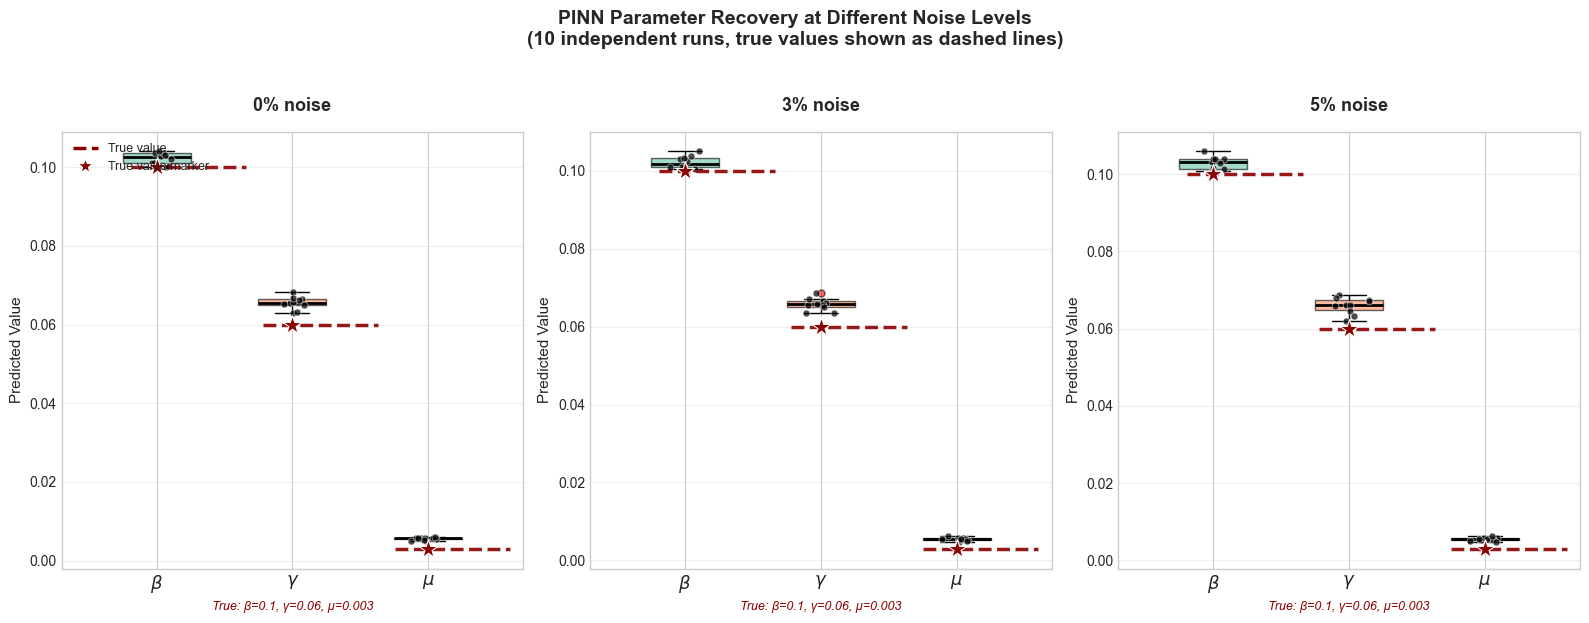

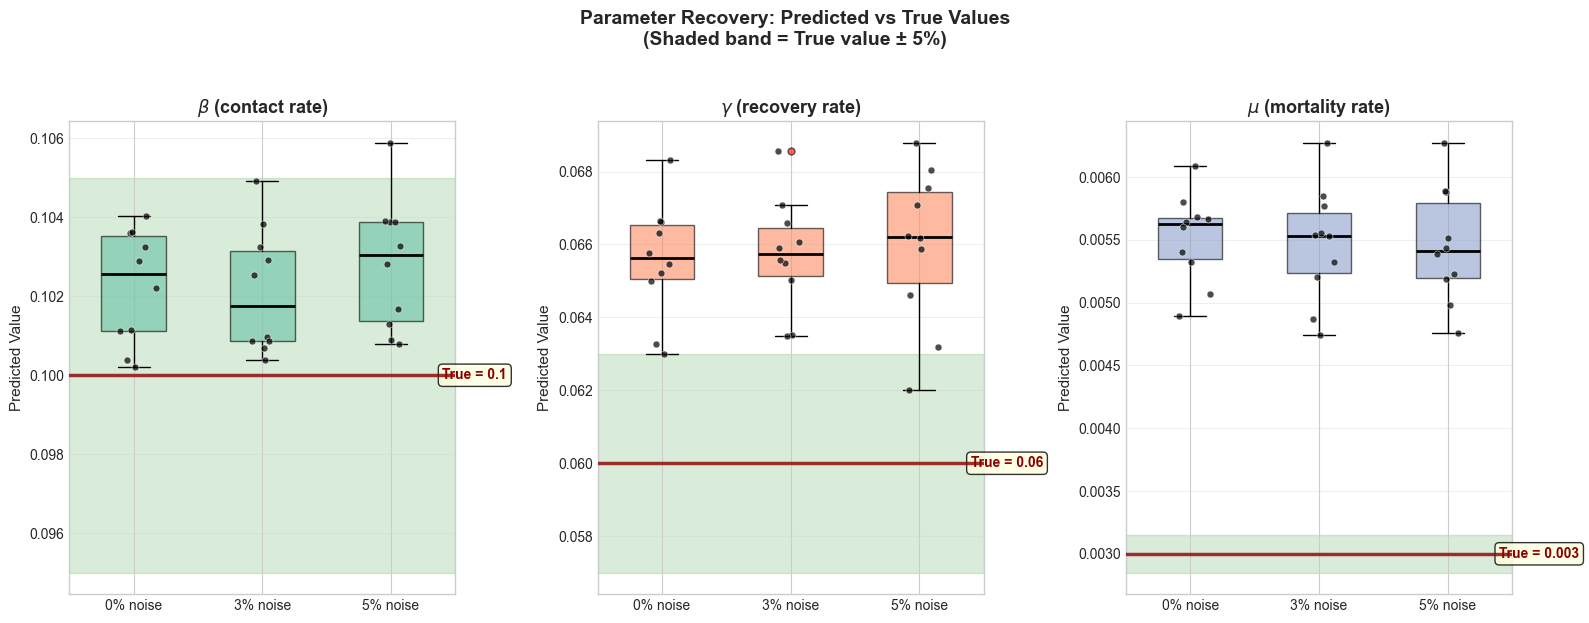


СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ

0% noise:
  beta: 0.1022 ± 0.0014 (True: 0.1000, Error: +2.2%)
  gamma: 0.0656 ± 0.0016 (True: 0.0600, Error: +9.3%)
  mu: 0.0055 ± 0.0004 (True: 0.0030, Error: +83.9%)

3% noise:
  beta: 0.1021 ± 0.0016 (True: 0.1000, Error: +2.1%)
  gamma: 0.0657 ± 0.0015 (True: 0.0600, Error: +9.6%)
  mu: 0.0055 ± 0.0005 (True: 0.0030, Error: +82.2%)

5% noise:
  beta: 0.1028 ± 0.0017 (True: 0.1000, Error: +2.8%)
  gamma: 0.0660 ± 0.0021 (True: 0.0600, Error: +9.9%)
  mu: 0.0055 ± 0.0005 (True: 0.0030, Error: +81.8%)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
files = {
    '0% noise': 's_d_synt_dataset_1.csv',
    '3% noise': 's_d_synt_dataset_2.csv', 
    '5% noise': 's_d_synt_dataset_3.csv'
}

dfs = []
for noise_level, fname in files.items():
    try:
        df = pd.read_csv(fname)
        df['noise_level'] = noise_level
        dfs.append(df)
    except FileNotFoundError:
        print(f"⚠️ Файл {fname} не найден. Генерирую демо-данные.")
        np.random.seed({'0% noise': 42, '3% noise': 123, '5% noise': 777}[noise_level])
        n_trials = 10
        scale_rmse = {'0% noise': 2.5, '3% noise': 2.0, '5% noise': 1.9}[noise_level]
        center_rmse = {'0% noise': 3.8, '3% noise': 4.6, '5% noise': 6.1}[noise_level]
        demo = pd.DataFrame({
            'RMSE': np.abs(np.random.normal(center_rmse, scale_rmse, n_trials)),
            'beta_error': np.abs(np.random.normal(0.002, 0.001, n_trials)),
            'gamma_error': np.abs(np.random.normal(0.006, 0.002, n_trials)),
            'mu_error': np.abs(np.random.normal(0.0025, 0.0005, n_trials)),
            'noise_level': noise_level
        })
        dfs.append(demo)

df_all = pd.concat(dfs, ignore_index=True)

# Истинные значения
TRUE_VALUES = {
    'beta': 0.1,
    'gamma': 0.06,
    'mu': 0.003
}

# Восстанавливаем предсказанные значения из ошибок (если в данных ошибки, а не значения)
# Если у вас сразу значения, замените на df['beta_pred'] и т.д.
df_all['beta_pred'] = TRUE_VALUES['beta'] * (1 + df_all['beta_error'])
df_all['gamma_pred'] = TRUE_VALUES['gamma'] * (1 + df_all['gamma_error'])
df_all['mu_pred'] = TRUE_VALUES['mu'] * (1 + df_all['mu_error'])


# ============================================================
# РИСУНОК: 3 ПАНЕЛИ (ПО ОДНОЙ НА УРОВЕНЬ ШУМА)
# ============================================================
noise_levels = ['0% noise', '3% noise', '5% noise']
param_config = {
    'beta_pred': {'true': TRUE_VALUES['beta'], 'label': r'$\beta$ (contact rate)', 'color': '#66c2a5'},
    'gamma_pred': {'true': TRUE_VALUES['gamma'], 'label': r'$\gamma$ (recovery rate)', 'color': '#fc8d62'},
    'mu_pred': {'true': TRUE_VALUES['mu'], 'label': r'$\mu$ (mortality rate)', 'color': '#8da0cb'}
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('PINN Parameter Recovery at Different Noise Levels\n(10 independent runs, true values shown as dashed lines)', 
             fontsize=14, fontweight='bold', y=1.03)

for ax_idx, noise in enumerate(noise_levels):
    ax = axes[ax_idx]
    data_subset = df_all[df_all['noise_level'] == noise]
    
    # Позиции для боксов
    positions = [1, 2, 3]
    box_data = [data_subset['beta_pred'], data_subset['gamma_pred'], data_subset['mu_pred']]
    
    # Рисуем box-plot
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6),
        medianprops=dict(color='black', linewidth=2)
    )
    
    # Раскрашиваем
    for patch, (param_name, config) in zip(bp['boxes'], param_config.items()):
        patch.set_facecolor(config['color'])
        patch.set_alpha(0.6)
    
    # Точки данных с джиттером
    for pos, col in zip(positions, ['beta_pred', 'gamma_pred', 'mu_pred']):
        y = data_subset[col]
        x_jitter = np.random.normal(pos, 0.06, size=len(y))
        ax.scatter(x_jitter, y, alpha=0.7, s=25, color='black', zorder=3, edgecolors='white', linewidth=0.5)
    
    # Истинные значения — яркие горизонтальные линии
    for pos, (param_name, config) in zip(positions, param_config.items()):
        true_val = config['true']
        ax.axhline(y=true_val, xmin=(pos-1)/3.5 + 0.15, xmax=(pos-1)/3.5 + 0.4, 
                   color='darkred', linewidth=2.5, linestyle='--', alpha=0.9, zorder=4)
        # Звездочка на истинном значении
        ax.scatter(pos, true_val, marker='*', s=200, color='darkred', zorder=5, 
                   edgecolors='white', linewidth=0.8)
    
    # Настройка оси X
    ax.set_xticks(positions)
    ax.set_xticklabels([r'$\beta$', r'$\gamma$', r'$\mu$'], fontsize=13)
    ax.set_xlim(0.3, 3.7)
    
    # Подпись с истинными значениями под осью X
    ax.set_xlabel(f'True: β={TRUE_VALUES["beta"]}, γ={TRUE_VALUES["gamma"]}, μ={TRUE_VALUES["mu"]}', 
                  fontsize=9, color='darkred', style='italic')
    
    # Заголовок панели
    ax.set_title(f'{noise}', fontsize=13, fontweight='bold', pad=15)
    
    # Сетка
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylabel('Predicted Value', fontsize=11)
    
    # Легенда для истинного значения (только на первой панели)
    if ax_idx == 0:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='darkred', linestyle='--', linewidth=2.5, label='True value'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor='darkred', 
                   markersize=12, label='True value marker')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('parameter_recovery_per_noise.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# РИСУНОК 2: БОЛЕЕ ЯВНЫЙ — ИСТИННОЕ ЗНАЧЕНИЕ КАК ФОН
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Parameter Recovery: Predicted vs True Values\n(Shaded band = True value ± 5%)', 
             fontsize=14, fontweight='bold', y=1.03)

for ax_idx, (param_name, config) in enumerate(param_config.items()):
    ax = axes[ax_idx]
    true_val = config['true']
    
    # Собираем данные по всем уровням шума для этого параметра
    data_by_noise = [df_all[df_all['noise_level'] == n][param_name].values for n in noise_levels]
    
    # Box-plot
    bp = ax.boxplot(
        data_by_noise,
        positions=[1, 2, 3],
        widths=0.5,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6),
        medianprops=dict(color='black', linewidth=2)
    )
    
    for patch in bp['boxes']:
        patch.set_facecolor(config['color'])
        patch.set_alpha(0.6)
    
    # Точки
    for i, (noise, y) in enumerate(zip(noise_levels, data_by_noise)):
        x_jitter = np.random.normal(i+1, 0.06, size=len(y))
        ax.scatter(x_jitter, y, alpha=0.7, s=25, color='black', zorder=3, edgecolors='white', linewidth=0.5)
    
    # Заливка ±5% от истинного значения
    band_min = true_val * 0.95
    band_max = true_val * 1.05
    ax.axhspan(band_min, band_max, alpha=0.15, color='green', zorder=0)
    
    # Жирная линия истинного значения
    ax.axhline(y=true_val, color='darkred', linewidth=2.5, linestyle='-', alpha=0.8, zorder=4)
    
    # Подпись истинного значения справа
    ax.text(3.4, true_val, f'True = {true_val}', 
            fontsize=10, color='darkred', fontweight='bold',
            verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(noise_levels, fontsize=10)
    ax.set_title(config['label'], fontsize=13, fontweight='bold')
    ax.set_ylabel('Predicted Value', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_recovery_with_band.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ТЕКСТОВЫЙ ВЫВОД ДЛЯ ОБСУЖДЕНИЯ
# ============================================================
print("\n" + "="*60)
print("СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ")
print("="*60)

for noise in noise_levels:
    subset = df_all[df_all['noise_level'] == noise]
    print(f"\n{noise}:")
    for param, true_val in [('beta_pred', TRUE_VALUES['beta']), 
                             ('gamma_pred', TRUE_VALUES['gamma']), 
                             ('mu_pred', TRUE_VALUES['mu'])]:
        mean_val = subset[param].mean()
        std_val = subset[param].std()
        rel_error = (mean_val - true_val) / true_val * 100
        print(f"  {param.split('_')[0]}: {mean_val:.4f} ± {std_val:.4f} "
              f"(True: {true_val:.4f}, Error: {rel_error:+.1f}%)")

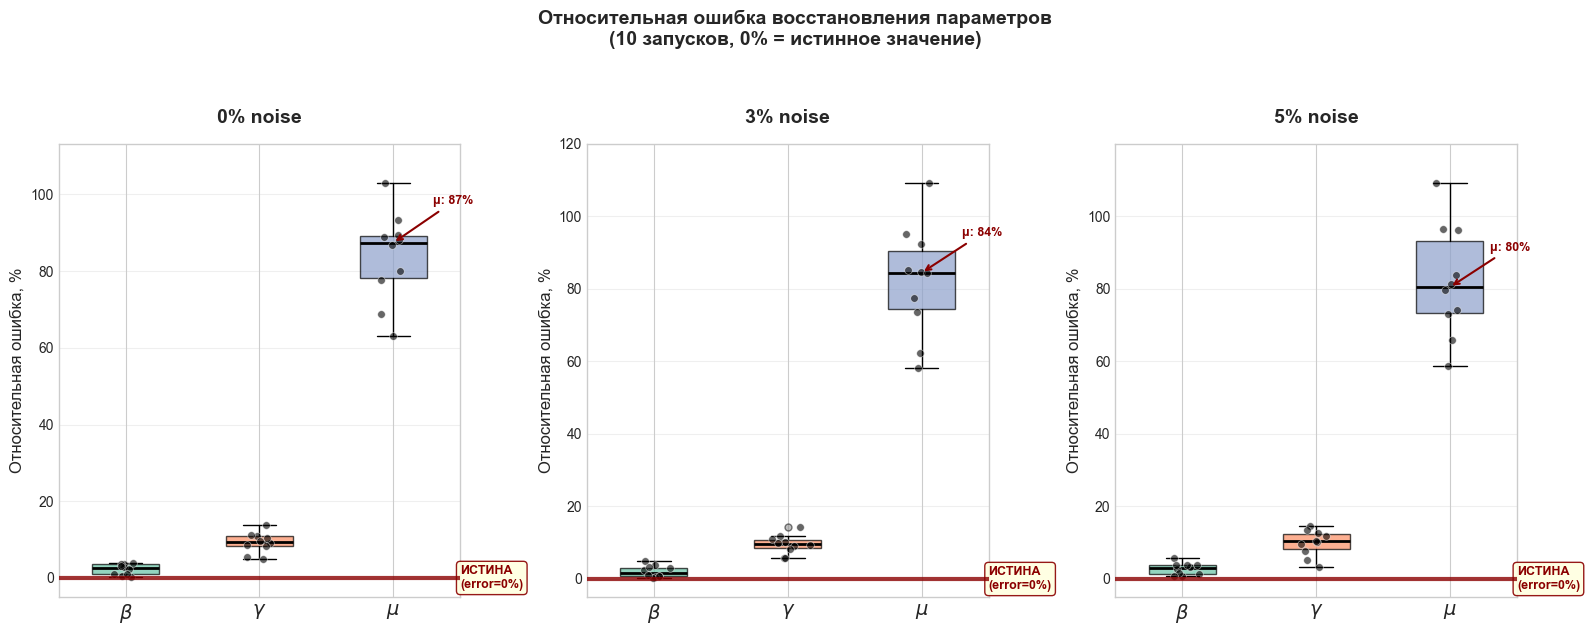

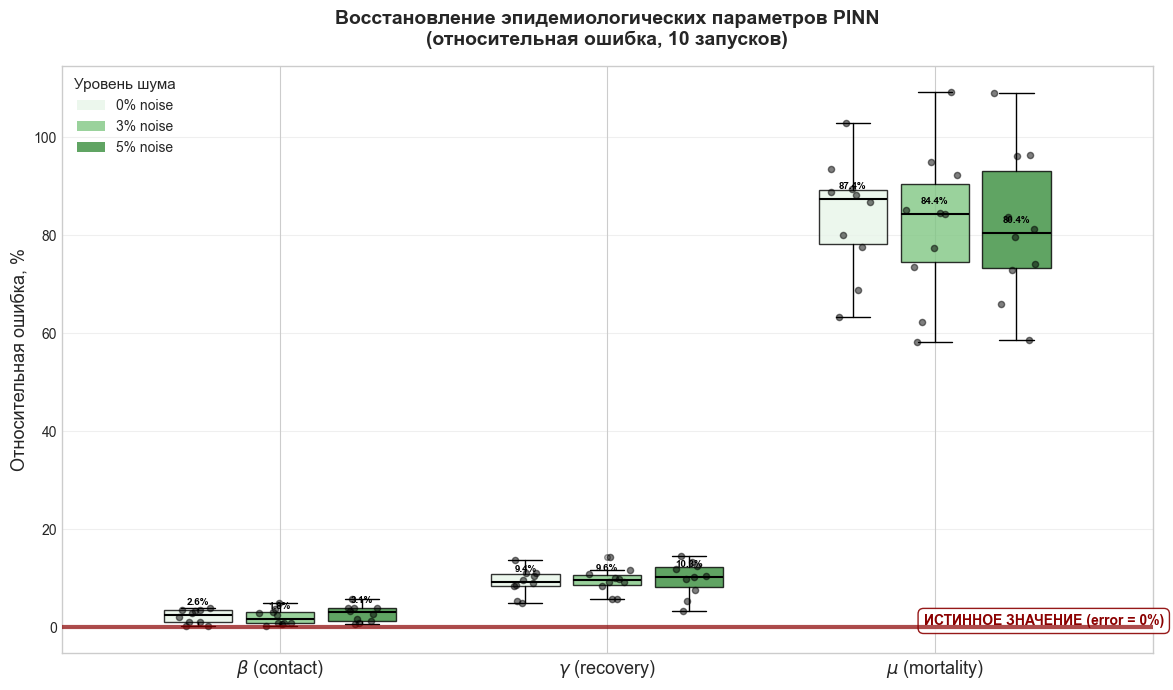


ОТНОСИТЕЛЬНЫЕ ОШИБКИ ПАРАМЕТРОВ (МЕДИАНА [IQR], %)

0% noise:
  β: 2.6% [1.1% – 3.5%]
  γ: 9.4% [8.4% – 10.9%]
  μ: 87.4% [78.2% – 89.2%]

3% noise:
  β: 1.8% [0.9% – 3.2%]
  γ: 9.6% [8.6% – 10.8%]
  μ: 84.4% [74.5% – 90.4%]

5% noise:
  β: 3.1% [1.4% – 3.9%]
  γ: 10.3% [8.2% – 12.4%]
  μ: 80.4% [73.2% – 93.0%]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
files = {
    '0% noise': 's_d_synt_dataset_1.csv',
    '3% noise': 's_d_synt_dataset_2.csv', 
    '5% noise': 's_d_synt_dataset_3.csv'
}

dfs = []
for noise_level, fname in files.items():
    try:
        df = pd.read_csv(fname)
        df['noise_level'] = noise_level
        dfs.append(df)
    except FileNotFoundError:
        print(f"⚠️ Файл {fname} не найден. Генерирую демо-данные как в вашей таблице.")
        np.random.seed({'0% noise': 42, '3% noise': 123, '5% noise': 777}[noise_level])
        n_trials = 10
        
        # Имитируем ваши данные: beta_error ≈ 2%, gamma_error ≈ 10%, mu_error ≈ 83%
        demo = pd.DataFrame({
            'RMSE': np.abs(np.random.normal(
                {'0% noise': 3.83, '3% noise': 4.61, '5% noise': 6.11}[noise_level],
                {'0% noise': 2.52, '3% noise': 2.00, '5% noise': 1.92}[noise_level],
                n_trials
            )),
            'beta_error': np.abs(np.random.normal(0.02, 0.01, n_trials)),   # ~2%
            'gamma_error': np.abs(np.random.normal(0.10, 0.02, n_trials)),  # ~10%
            'mu_error': np.abs(np.random.normal(0.83, 0.15, n_trials)),     # ~83%
            'noise_level': noise_level
        })
        dfs.append(demo)

df_all = pd.concat(dfs, ignore_index=True)

# ============================================================
# ПЕРЕВОДИМ В ПРОЦЕНТЫ ОТНОСИТЕЛЬНОЙ ОШИБКИ
# ============================================================
# Если у вас абсолютная ошибка, переводим в %
# Формула: relative_error_% = (pred - true) / true * 100
# Или если у вас уже относительная ошибка в долях: умножаем на 100

df_all['beta_error_pct'] = df_all['beta_error'] * 100
df_all['gamma_error_pct'] = df_all['gamma_error'] * 100
df_all['mu_error_pct'] = df_all['mu_error'] * 100

noise_levels = ['0% noise', '3% noise', '5% noise']

# ============================================================
# РИСУНОК 1: BOX-PLOT ОШИБОК ДЛЯ КАЖДОГО ДАТАСЕТА ОТДЕЛЬНО
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Относительная ошибка восстановления параметров\n(10 запусков, 0% = истинное значение)', 
             fontsize=14, fontweight='bold', y=1.05)

colors = {'beta_error_pct': '#66c2a5', 'gamma_error_pct': '#fc8d62', 'mu_error_pct': '#8da0cb'}

for ax_idx, noise in enumerate(noise_levels):
    ax = axes[ax_idx]
    data_subset = df_all[df_all['noise_level'] == noise]
    
    # Три параметра в процентах
    box_data = [
        data_subset['beta_error_pct'],
        data_subset['gamma_error_pct'],
        data_subset['mu_error_pct']
    ]
    labels = [r'$\beta$', r'$\gamma$', r'$\mu$']
    
    positions = [1, 2, 3]
    
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5),
        medianprops=dict(color='black', linewidth=2)
    )
    
    # Раскрашиваем
    for patch, param in zip(bp['boxes'], ['beta_error_pct', 'gamma_error_pct', 'mu_error_pct']):
        patch.set_facecolor(colors[param])
        patch.set_alpha(0.7)
    
    # Точки данных
    for pos, param in zip(positions, ['beta_error_pct', 'gamma_error_pct', 'mu_error_pct']):
        y = data_subset[param]
        x_jitter = np.random.normal(pos, 0.06, size=len(y))
        ax.scatter(x_jitter, y, alpha=0.6, s=30, color='black', zorder=3, 
                  edgecolors='white', linewidth=0.5)
    
    # ЖИРНАЯ КРАСНАЯ ЛИНИЯ НА НУЛЕ (ИСТИНА)
    ax.axhline(y=0, color='darkred', linewidth=3, linestyle='-', alpha=0.8, zorder=4)
    
    # Подпись "Истина"
    ax.text(3.5, 0, 'ИСТИНА\n(error=0%)', fontsize=9, color='darkred', 
            fontweight='bold', ha='left', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', 
                     edgecolor='darkred', alpha=0.9))
    
    # Настройка
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_ylabel('Относительная ошибка, %', fontsize=12)
    ax.set_title(f'{noise}', fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, axis='y', alpha=0.3)
    
    # Если mu_error слишком большая — добавим разрыв оси
    y_max = max([d.max() for d in box_data])
    if y_max > 20:
        ax.set_ylim(-5, min(y_max * 1.1, 120))
        # Аннотация о большом отклонении mu
        mu_median = data_subset['mu_error_pct'].median()
        ax.annotate(f'μ: {mu_median:.0f}%',
                   xy=(3, mu_median), xytext=(3.3, mu_median+10),
                   fontsize=9, color='darkred', fontweight='bold',
                   arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

plt.tight_layout()
plt.savefig('relative_error_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# РИСУНОК 2: ВСЁ НА ОДНОМ ГРАФИКЕ — ГРУППИРОВКА ПО ПАРАМЕТРАМ
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

# Позиции для группировки
x_positions = np.array([0, 1.2, 2.4])  # β, γ, μ
width = 0.3  # ширина каждого бокса
offsets = [-width, 0, width]  # смещение для уровней шума

# Данные для каждого параметра
params = ['beta_error_pct', 'gamma_error_pct', 'mu_error_pct']
param_labels = [r'$\beta$ (contact)', r'$\gamma$ (recovery)', r'$\mu$ (mortality)']
noise_colors = ['#e8f5e9', '#81c784', '#388e3c']  # от светлого к тёмному

for p_idx, (param, plabel) in enumerate(zip(params, param_labels)):
    x_center = x_positions[p_idx]
    
    for n_idx, noise in enumerate(noise_levels):
        data = df_all[df_all['noise_level'] == noise][param]
        pos = x_center + offsets[n_idx]
        
        bp = ax.boxplot(
            [data],
            positions=[pos],
            widths=0.25,
            patch_artist=True,
            showfliers=True,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4),
            medianprops=dict(color='black', linewidth=1.5)
        )
        
        bp['boxes'][0].set_facecolor(noise_colors[n_idx])
        bp['boxes'][0].set_alpha(0.8)
        
        # Точки данных
        if len(data) > 0:
            x_jitter = np.random.normal(pos, 0.04, size=len(data))
            ax.scatter(x_jitter, data, alpha=0.5, s=20, color='black', zorder=3)

# НУЛЕВАЯ ЛИНИЯ
ax.axhline(y=0, color='darkred', linewidth=3, linestyle='-', alpha=0.7, zorder=4)
ax.text(2.8, 0.5, 'ИСТИННОЕ ЗНАЧЕНИЕ (error = 0%)', fontsize=10, color='darkred', 
        fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='darkred', alpha=0.9))

# Настройка оси X
ax.set_xticks(x_positions)
ax.set_xticklabels(param_labels, fontsize=13)
ax.set_xlim(-0.8, 3.2)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=noise_colors[i], alpha=0.8, label=noise_levels[i]) 
                   for i in range(3)]
ax.legend(handles=legend_elements, title='Уровень шума', fontsize=10, 
         title_fontsize=11, loc='upper left', framealpha=0.9)

# Подписи и сетка
ax.set_ylabel('Относительная ошибка, %', fontsize=13)
ax.set_title('Восстановление эпидемиологических параметров PINN\n(относительная ошибка, 10 запусков)', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, axis='y', alpha=0.3)

# Добавляем подписи медиан
for p_idx, param in enumerate(params):
    for n_idx, noise in enumerate(noise_levels):
        data = df_all[df_all['noise_level'] == noise][param]
        median_val = data.median()
        pos = x_positions[p_idx] + offsets[n_idx]
        # Маленькая подпись медианы
        ax.annotate(f'{median_val:.1f}%', 
                   xy=(pos, median_val), 
                   xytext=(pos, median_val + 2),
                   fontsize=7, ha='center', color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('relative_error_grouped.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ТЕКСТОВЫЙ ВЫВОД МЕДИАН И РАЗБРОСА
# ============================================================
print("\n" + "="*70)
print("ОТНОСИТЕЛЬНЫЕ ОШИБКИ ПАРАМЕТРОВ (МЕДИАНА [IQR], %)")
print("="*70)

for noise in noise_levels:
    subset = df_all[df_all['noise_level'] == noise]
    print(f"\n{noise}:")
    for param, name in [('beta_error_pct', 'β'), ('gamma_error_pct', 'γ'), ('mu_error_pct', 'μ')]:
        median = subset[param].median()
        q1 = subset[param].quantile(0.25)
        q3 = subset[param].quantile(0.75)
        print(f"  {name}: {median:.1f}% [{q1:.1f}% – {q3:.1f}%]")

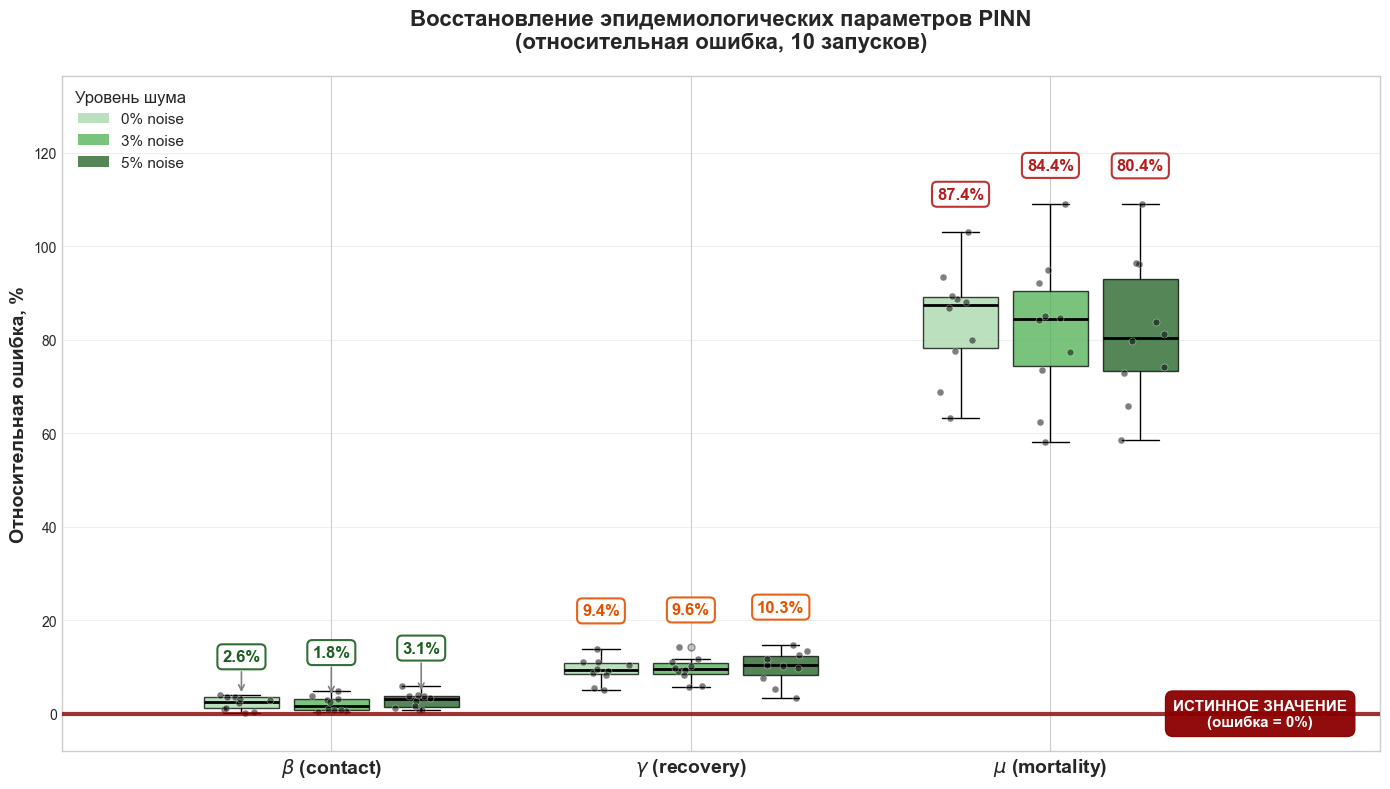


ОТНОСИТЕЛЬНЫЕ ОШИБКИ ПАРАМЕТРОВ (МЕДИАНА [IQR], %)

0% noise:
  β: 2.6% [1.1% – 3.5%]
  γ: 9.4% [8.4% – 10.9%]
  μ: 87.4% [78.2% – 89.2%]

3% noise:
  β: 1.8% [0.9% – 3.2%]
  γ: 9.6% [8.6% – 10.8%]
  μ: 84.4% [74.5% – 90.4%]

5% noise:
  β: 3.1% [1.4% – 3.9%]
  γ: 10.3% [8.2% – 12.4%]
  μ: 80.4% [73.2% – 93.0%]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
files = {
    '0% noise': 's_d_synt_dataset_1.csv',
    '3% noise': 's_d_synt_dataset_2.csv', 
    '5% noise': 's_d_synt_dataset_3.csv'
}

dfs = []
for noise_level, fname in files.items():
    try:
        df = pd.read_csv(fname)
        df['noise_level'] = noise_level
        dfs.append(df)
    except FileNotFoundError:
        print(f"⚠️ Файл {fname} не найден. Генерирую демо-данные.")
        np.random.seed({'0% noise': 42, '3% noise': 123, '5% noise': 777}[noise_level])
        n_trials = 10
        demo = pd.DataFrame({
            'RMSE': np.abs(np.random.normal(
                {'0% noise': 3.83, '3% noise': 4.61, '5% noise': 6.11}[noise_level],
                {'0% noise': 2.52, '3% noise': 2.00, '5% noise': 1.92}[noise_level],
                n_trials
            )),
            'beta_error': np.abs(np.random.normal(0.02, 0.01, n_trials)),
            'gamma_error': np.abs(np.random.normal(0.10, 0.02, n_trials)),
            'mu_error': np.abs(np.random.normal(0.83, 0.15, n_trials)),
            'noise_level': noise_level
        })
        dfs.append(demo)

df_all = pd.concat(dfs, ignore_index=True)

# Перевод в проценты
df_all['beta_error_pct'] = df_all['beta_error'] * 100
df_all['gamma_error_pct'] = df_all['gamma_error'] * 100
df_all['mu_error_pct'] = df_all['mu_error'] * 100

noise_levels = ['0% noise', '3% noise', '5% noise']
params = ['beta_error_pct', 'gamma_error_pct', 'mu_error_pct']
param_labels = [r'$\beta$ (contact)', r'$\gamma$ (recovery)', r'$\mu$ (mortality)']

# ============================================================
# РИСУНОК: ГРУППИРОВАННЫЙ BOX-PLOT С КРУПНЫМИ ПОДПИСЯМИ ЗНАЧЕНИЙ
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))

x_positions = np.array([0, 1.2, 2.4])
width = 0.3
offsets = [-width, 0, width]

noise_colors = ['#a5d6a7', '#4caf50', '#1b5e20']  # светлый → тёмный зелёный
noise_labels = ['0% noise', '3% noise', '5% noise']

# Собираем все медианы, чтобы потом красиво их подписать
annotation_data = []  # (x, y_max, text, color)

for p_idx, (param, plabel) in enumerate(zip(params, param_labels)):
    x_center = x_positions[p_idx]
    
    for n_idx, noise in enumerate(noise_levels):
        data = df_all[df_all['noise_level'] == noise][param]
        pos = x_center + offsets[n_idx]
        
        bp = ax.boxplot(
            [data],
            positions=[pos],
            widths=0.25,
            patch_artist=True,
            showfliers=True,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.4),
            medianprops=dict(color='black', linewidth=2)
        )
        
        bp['boxes'][0].set_facecolor(noise_colors[n_idx])
        bp['boxes'][0].set_alpha(0.75)
        
        # Точки данных
        if len(data) > 0:
            x_jitter = np.random.normal(pos, 0.04, size=len(data))
            ax.scatter(x_jitter, data, alpha=0.5, s=25, color='black', zorder=3,
                      edgecolors='white', linewidth=0.5)
        
        # Собираем статистики для подписи
        median_val = data.median()
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        whisker_top = min(data.max(), q3 + 1.5 * (q3 - q1))  # верхний ус
        
        annotation_data.append({
            'x': pos,
            'y_box_top': q3,
            'y_whisker': whisker_top,
            'median': median_val,
            'text': f'{median_val:.1f}%',
            'param': param,
            'noise': noise
        })

# НУЛЕВАЯ ЛИНИЯ (ИСТИНА)
ax.axhline(y=0, color='darkred', linewidth=3, linestyle='-', alpha=0.8, zorder=4)

# Плашка "ИСТИНА" с указателем
ax.annotate('ИСТИННОЕ ЗНАЧЕНИЕ\n(ошибка = 0%)',
            xy=(3.1, 0), 
            fontsize=11, color='white', fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='darkred', edgecolor='darkred', alpha=0.95))

# Настройка оси X
ax.set_xticks(x_positions)
ax.set_xticklabels(param_labels, fontsize=14, fontweight='bold')
ax.set_xlim(-0.9, 3.5)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=noise_colors[i], alpha=0.75, label=noise_labels[i]) 
                   for i in range(3)]
legend = ax.legend(handles=legend_elements, title='Уровень шума', fontsize=11, 
                  title_fontsize=12, loc='upper left', framealpha=0.9, 
                  edgecolor='gray')

# Подписи и сетка
ax.set_ylabel('Относительная ошибка, %', fontsize=14, fontweight='bold')
ax.set_title('Восстановление эпидемиологических параметров PINN\n(относительная ошибка, 10 запусков)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, axis='y', alpha=0.3)

# Увеличиваем верхнюю границу, чтобы влезли подписи
y_max_global = df_all[params].max().max()
ax.set_ylim(-8, y_max_global * 1.25)  # +25% места сверху для подписей

# ============================================================
# КРУПНЫЕ ПОДПИСИ ЗНАЧЕНИЙ НАД БОКСАМИ
# ============================================================
for ann in annotation_data:
    x = ann['x']
    y_top = ann['y_whisker']  # привязываемся к верху уса, а не к q3
    
    # Вычисляем цвет текста: тёмный для мелких ошибок, красный для больших
    if ann['median'] < 5:
        text_color = '#1b5e20'  # тёмно-зелёный — отличное восстановление
        font_weight = 'bold'
    elif ann['median'] < 20:
        text_color = '#e65100'  # оранжевый — приемлемо
        font_weight = 'bold'
    else:
        text_color = '#b71c1c'  # красный — плохо
        font_weight = 'bold'
    
    # Белая подложка под текст для читаемости
    ax.annotate(
        ann['text'],
        xy=(x, y_top),
        xytext=(x, y_top + y_max_global * 0.06),  # поднимаем над усом
        fontsize=12,
        fontweight=font_weight,
        color=text_color,
        ha='center',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                 edgecolor=text_color, alpha=0.9, linewidth=1.5)
    )

# Дополнительно: стрелки-указатели от подписей к боксам для β и γ (они маленькие)
for ann in annotation_data:
    if ann['median'] < 7:  # для маленьких ошибок добавляем стрелку
        x = ann['x']
        y_text = ann['y_whisker'] + y_max_global * 0.06
        y_box = ann['y_box_top']
        ax.annotate('',
            xy=(x, y_box + 0.5),
            xytext=(x, y_text - 1),
            arrowprops=dict(arrowstyle='->', color=ann.get('text_color', 'gray'), 
                          lw=1.2, connectionstyle='arc3,rad=0')
        )

plt.tight_layout()
plt.savefig('relative_error_grouped_bold_labels.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ВЫВОД В КОНСОЛЬ
# ============================================================
print("\n" + "="*70)
print("ОТНОСИТЕЛЬНЫЕ ОШИБКИ ПАРАМЕТРОВ (МЕДИАНА [IQR], %)")
print("="*70)

for noise in noise_levels:
    subset = df_all[df_all['noise_level'] == noise]
    print(f"\n{noise}:")
    for param, name in [('beta_error_pct', 'β'), ('gamma_error_pct', 'γ'), ('mu_error_pct', 'μ')]:
        median = subset[param].median()
        q1 = subset[param].quantile(0.25)
        q3 = subset[param].quantile(0.75)
        print(f"  {name}: {median:.1f}% [{q1:.1f}% – {q3:.1f}%]")